In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, sharpe_ratio, results_table, optimize
from src.strategy import mean_reversion_strategy, momentum_strategy
from src.visualization import plot_performance

In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


## Mean Reversion, Window = 5

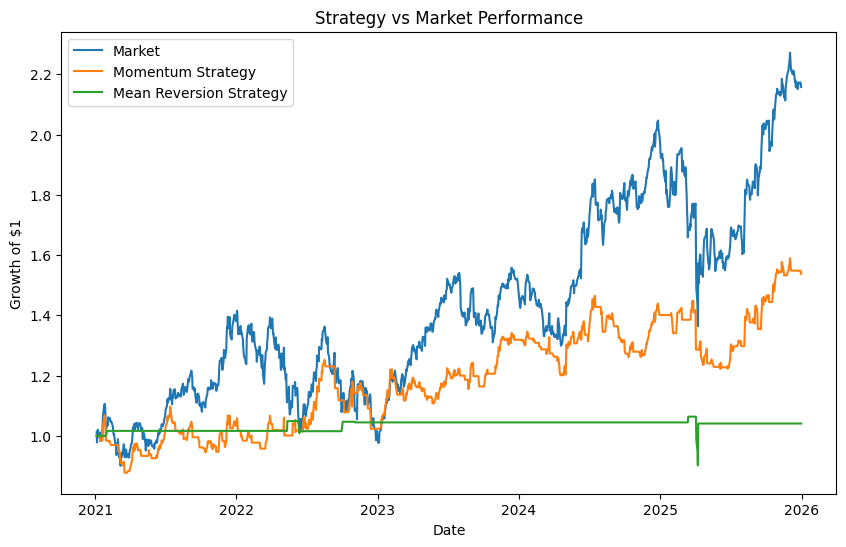

In [3]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 5)
df = momentum_strategy(df, window = 5)
df = backtest(df)

plot_performance(df)

In [4]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.568910,0.180697,-0.182804
2,Mean Reversion,0.134808,0.085902,-0.151435


## Mean Reversion, Window = 10

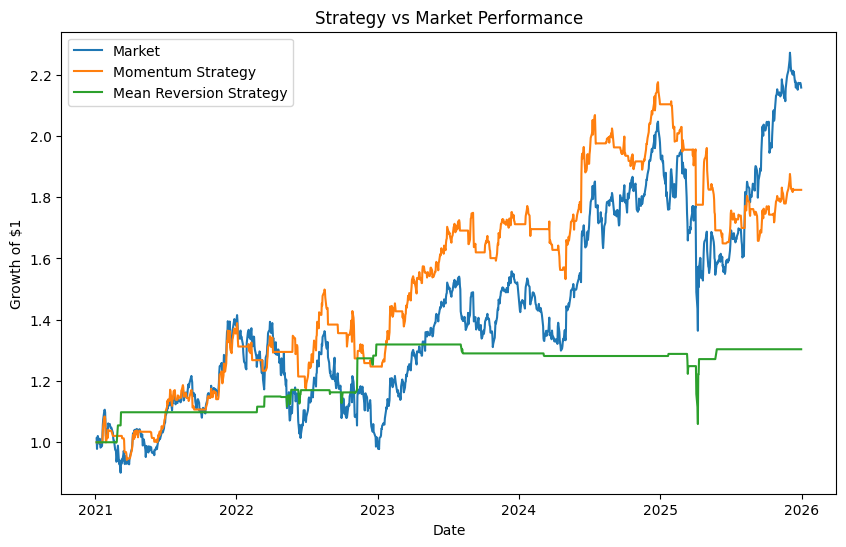

In [5]:
df = base_df.copy()
df = mean_reversion_strategy(df)
df = momentum_strategy(df)
df = backtest(df)

plot_performance(df)

In [6]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.758121,0.180887,-0.241998
2,Mean Reversion,0.536417,0.110165,-0.196905


## Mean Reversion, Window = 20

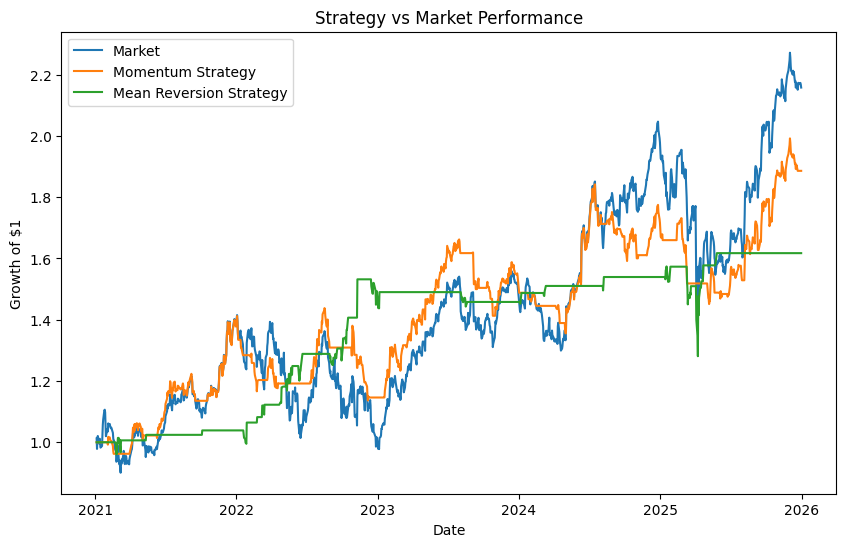

In [7]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 20)
df = momentum_strategy(df, window = 20)
df = backtest(df)

plot_performance(df)

In [8]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.809953,0.176537,-0.212237
2,Mean Reversion,0.768122,0.137774,-0.186215


## Mean Reversion, Window = 50

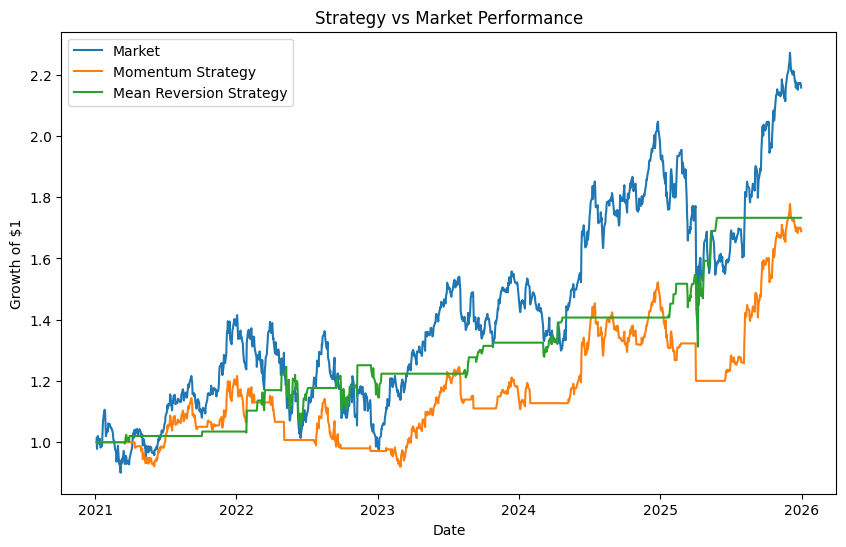

In [9]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 50)
df = momentum_strategy(df, window = 50)
df = backtest(df)

plot_performance(df)

In [10]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.676844,0.179370,-0.243725
2,Mean Reversion,0.780333,0.157039,-0.158242


## Best MR Window, Fixed Threshold Test

Mean Reversion
Market Returns Sharpe Ratio: 0.6934952059994559
Best Mean Reversion Strategy window: 48
Best Sharpe ratio: 0.8343


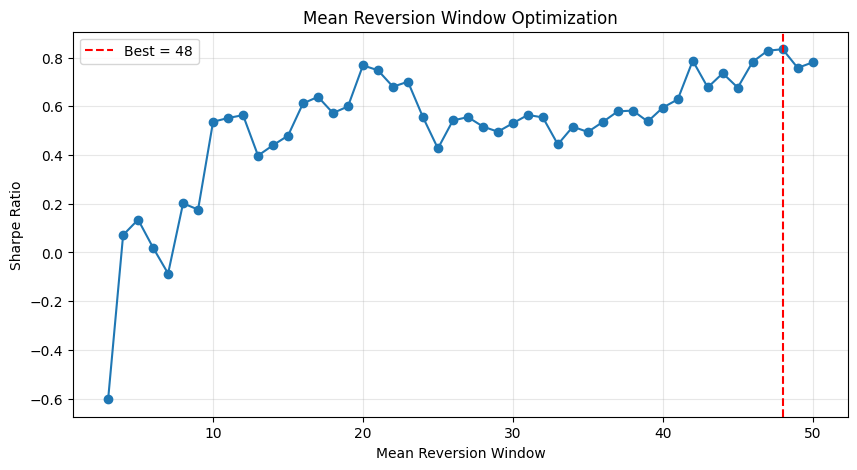

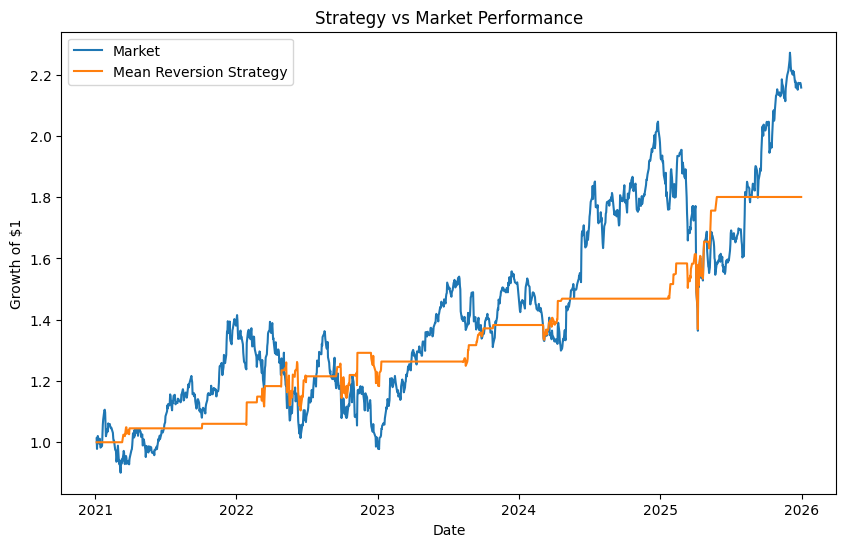

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Mean Reversion,0.834267,0.155950,-0.151435


In [11]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', [])
]
window = range(1, 51)

optimize(df, strategy, window)

In [12]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Mean Reversion,0.834267,0.155950,-0.151435


## Best MR Window & Threshold Test

Mean Reversion
Market Sharpe Ratio: 0.6935
Best window: 34
Best threshold: 0.03
Best Sharpe: 1.0670


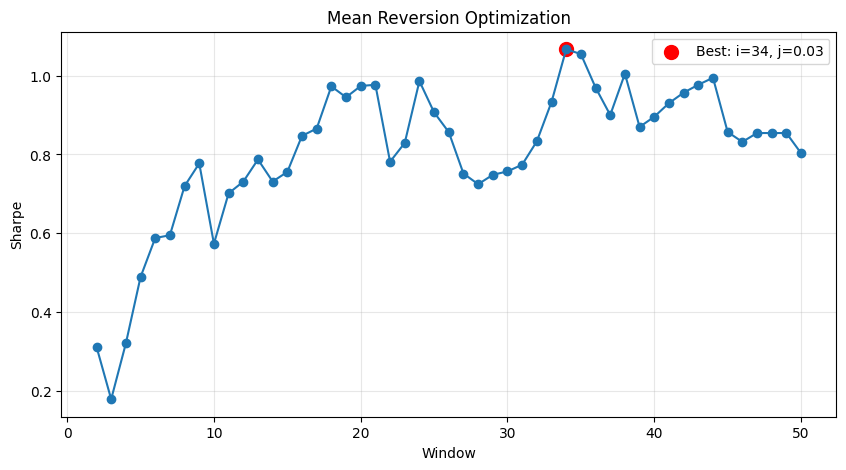

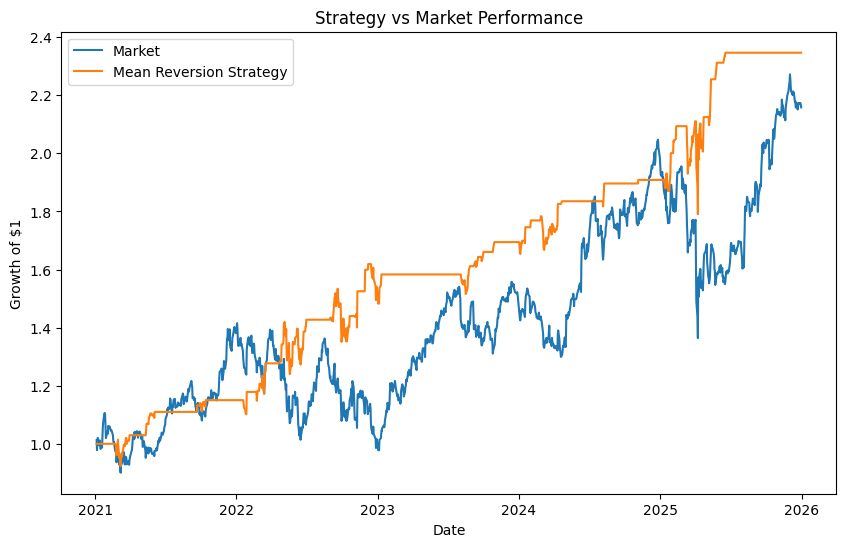

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Mean Reversion,1.067014,0.174654,-0.151435


In [13]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(1, 101))
]
window = range(1, 51)

optimize(df, strategy, window)

## Best Momentum vs Best Mean Reversion

Mean Reversion
Market Sharpe Ratio: 0.6935
Best window: 34
Best threshold: 0.03
Best Sharpe: 1.0670


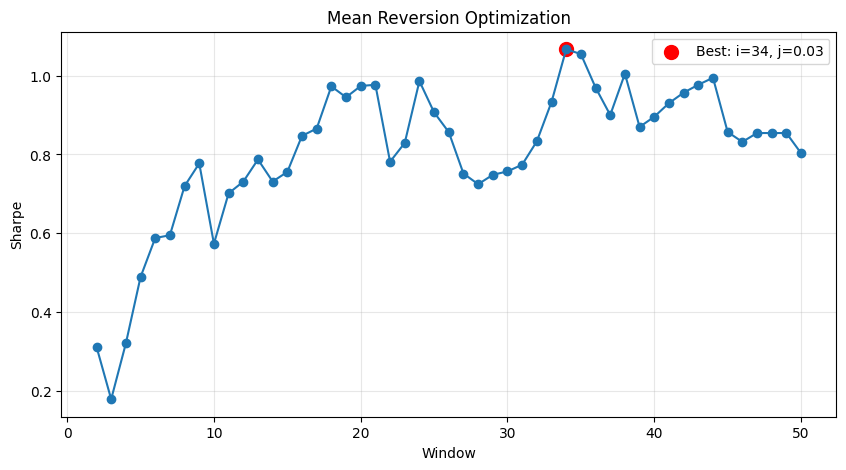

Momentum
Market Returns Sharpe Ratio: 0.6934952059994559
Best Momentum Strategy window: 6
Best Sharpe ratio: 0.9918


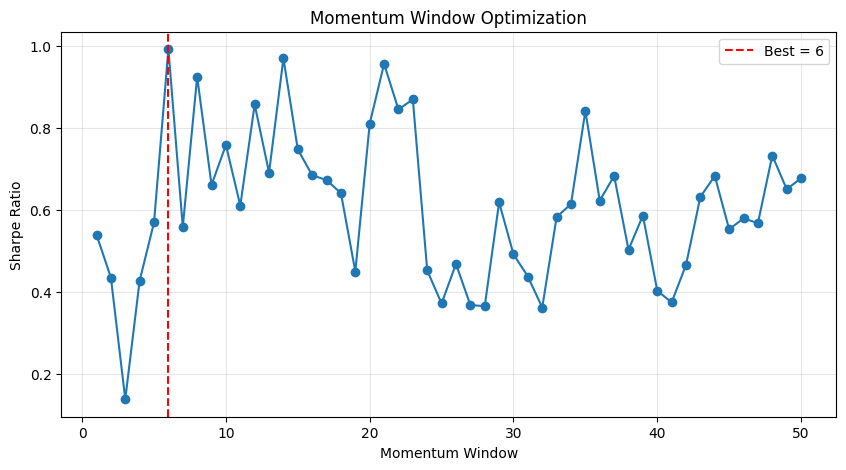

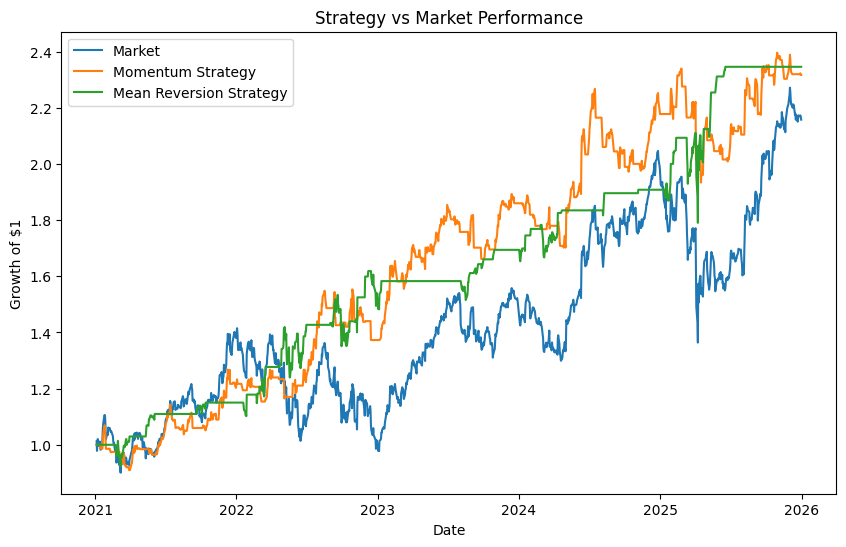

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.991820,0.188117,-0.173479
2,Mean Reversion,1.067014,0.174654,-0.151435


In [15]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(1, 101)),
    ('Momentum', momentum_strategy, 'mom', [])
]
window = range(1, 51)

optimize(df, strategy, window)